# Начало

In [48]:
import sys
import os
from typing import List, Tuple, Dict, Any
from tqdm import tqdm
# Добавляем корневую папку проекта в путь Python
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [2]:
from src.utils.cfg import load_config
config = load_config()


КОНФИГУРАЦИЯ ПРОЕКТА
   Проект: vectoratomcurves
   Версия: 1.0.0
   Автор: Polyakov Stepan
   Датасет: data/dataset_10000_1_filtered
   Устройство: cuda



In [3]:
cd ..

/home/stepan/VectorAtomCurves


# Загрузка датасета PDB

In [4]:
from src.data.loader import load_and_preprocess_pdb_files
dataset_path = config.get('dataset', {}).get('path', 'N/A')
print(dataset_path)
pdb_files, ca_points = load_and_preprocess_pdb_files(dataset_path)

/home/stepan/VectorAtomCurves/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data/dataset_10000_1_filtered
Загрузка PDB файлов...


Обработка файлов: 0it [00:00, ?it/s]
Обработка файлов:   1%|█▍                                                                                                                                                                                  | 44/5390 [00:00<00:12, 427.25it/s]/home/stepan/VectorAtomCurves/src/pdb/PDBFile.py:20: UserWarning: ERROR! Length atom_line = 0!!!
Path: data/dataset_10000_1_filtered/domains/5unh_A_3.pdb
  self.find_ca()
Обработка файлов:   3%|████▌                                                                                                                                                                              | 136/5390 [00:00<00:15, 332.99it/s]/home/stepan/VectorAtomCurves/src/pdb/PDBFile.py:20: UserWarning: ERROR! Length atom_line = 0!!!
Path: data/dataset_10000_1_filtered/domains/2vb9_B_2.pdb
  self.find_ca()
Обработка файлов:   3%|█████▊                                                                                                                    


Загружено 5329 файлов, ошибок: 61


In [11]:
# Получить все координаты всех атомов в pdb файле
pdb_files[0].get_point_cloud()

[[101.281, 134.232, 144.452],
 [97.558, 135.25, 144.521],
 [95.252, 135.78, 141.443],
 [97.115, 139.051, 140.624],
 [100.725, 138.382, 139.49],
 [100.139, 134.867, 138.027],
 [96.64, 135.852, 136.79],
 [98.358, 138.752, 135.022],
 [100.911, 136.462, 133.386],
 [98.25, 134.158, 131.951],
 [96.718, 137.171, 130.221],
 [100.078, 137.928, 128.629],
 [100.397, 134.3, 127.577],
 [97.019, 134.452, 125.888],
 [97.961, 137.686, 124.155],
 [100.963, 135.828, 122.771],
 [98.641, 133.005, 121.748],
 [96.263, 135.37, 119.954],
 [99.216, 136.763, 118.033],
 [100.198, 133.198, 117.189],
 [96.68, 132.513, 115.977],
 [96.724, 135.507, 113.653],
 [100.122, 134.477, 112.318],
 [99.022, 130.882, 111.758],
 [95.912, 132.058, 109.953],
 [97.855, 134.288, 107.594],
 [100.545, 131.697, 106.984],
 [98.68, 128.42, 106.659],
 [95.371, 129.672, 105.246],
 [95.617, 132.982, 103.399],
 [98.925, 132.717, 101.58],
 [98.856, 128.942, 101.154],
 [95.585, 129.027, 99.255],
 [96.778, 132.164, 97.487],
 [99.713, 130.131, 

In [13]:
# Получить список всех атомов со всеми характеристиками
pdb_files[0].getAtom()

[Atom(record_type='ATOM', serial=7467, name='N', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=101.841, y=132.848, z=144.429, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7468, name='CA', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=101.281, y=134.232, z=144.452, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7469, name='C', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=99.757, y=134.142, z=144.31, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7470, name='O', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=99.263, y=133.056, z=143.949, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7471, name='CB', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=101.927, y=135.099, z=143.352, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7472, name='CG1', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=103.425, y=134.809, z=143.224, occupancy=2.0, b_factor

In [15]:
#Список Ca-атомов с характеристиками
pdb_files[0].getCaAtom()

[Atom(record_type='ATOM', serial=7468, name='CA', alt_loc='', res_name='ILE', chain_id='H', res_seq=94, x=101.281, y=134.232, z=144.452, occupancy=2.0, b_factor=126.0),
 Atom(record_type='ATOM', serial=7476, name='CA', alt_loc='', res_name='THR', chain_id='H', res_seq=95, x=97.558, y=135.25, z=144.521, occupancy=2.0, b_factor=129.0),
 Atom(record_type='ATOM', serial=7483, name='CA', alt_loc='', res_name='PRO', chain_id='H', res_seq=96, x=95.252, y=135.78, z=141.443, occupancy=2.0, b_factor=130.0),
 Atom(record_type='ATOM', serial=7490, name='CA', alt_loc='', res_name='ARG', chain_id='H', res_seq=97, x=97.115, y=139.051, z=140.624, occupancy=2.0, b_factor=122.0),
 Atom(record_type='ATOM', serial=7501, name='CA', alt_loc='', res_name='GLU', chain_id='H', res_seq=98, x=100.725, y=138.382, z=139.49, occupancy=2.0, b_factor=110.0),
 Atom(record_type='ATOM', serial=7510, name='CA', alt_loc='', res_name='GLU', chain_id='H', res_seq=99, x=100.139, y=134.867, z=138.027, occupancy=2.0, b_factor=

In [18]:
# Храняться координаты ca-атомов
ca_points[0]

[[101.281, 134.232, 144.452],
 [97.558, 135.25, 144.521],
 [95.252, 135.78, 141.443],
 [97.115, 139.051, 140.624],
 [100.725, 138.382, 139.49],
 [100.139, 134.867, 138.027],
 [96.64, 135.852, 136.79],
 [98.358, 138.752, 135.022],
 [100.911, 136.462, 133.386],
 [98.25, 134.158, 131.951],
 [96.718, 137.171, 130.221],
 [100.078, 137.928, 128.629],
 [100.397, 134.3, 127.577],
 [97.019, 134.452, 125.888],
 [97.961, 137.686, 124.155],
 [100.963, 135.828, 122.771],
 [98.641, 133.005, 121.748],
 [96.263, 135.37, 119.954],
 [99.216, 136.763, 118.033],
 [100.198, 133.198, 117.189],
 [96.68, 132.513, 115.977],
 [96.724, 135.507, 113.653],
 [100.122, 134.477, 112.318],
 [99.022, 130.882, 111.758],
 [95.912, 132.058, 109.953],
 [97.855, 134.288, 107.594],
 [100.545, 131.697, 106.984],
 [98.68, 128.42, 106.659],
 [95.371, 129.672, 105.246],
 [95.617, 132.982, 103.399],
 [98.925, 132.717, 101.58],
 [98.856, 128.942, 101.154],
 [95.585, 129.027, 99.255],
 [96.778, 132.164, 97.487],
 [99.713, 130.131, 

# Интерполяция и добавление инвариантности

В данной работе мы работаем с ca-атомами, поэтому используем их

In [24]:
from src.preprocessing.curves import get_invariant_features
import numpy as np
example = ca_points[0]
features = get_invariant_features(np.array(example)) #Получаем инвариантное представление

In [26]:
features.shape

(76, 3)

In [29]:
from src.preprocessing.interpolation import resample_trajectory_cubic_spline

In [33]:
#Интерполяция
resampled = resample_trajectory_cubic_spline(features, k=512)
resampled # - получили 512 точек

array([[3.25432955e+01, 1.17000949e+00, 2.03430941e+00],
       [3.27470185e+01, 6.00017405e-01, 1.95060048e+00],
       [3.29318059e+01, 3.22527283e-02, 1.87122535e+00],
       ...,
       [1.81805651e+01, 9.19776231e+00, 3.15466460e+00],
       [1.85373862e+01, 9.28850140e+00, 2.60556511e+00],
       [1.89036335e+01, 9.36250571e+00, 2.03811997e+00]], shape=(512, 3))

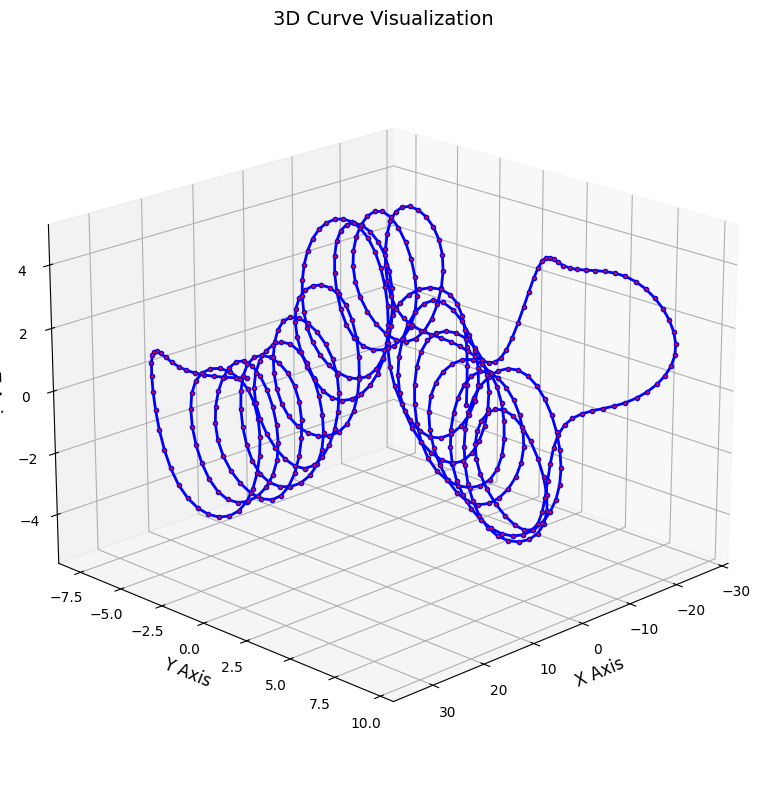

In [35]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = resampled[:, 0]
y = resampled[:, 1]
z = resampled[:, 2]

ax.plot(x, y, z, 
        linewidth=2, 
        color='blue',
        marker='o', 
        markersize=3,
        markerfacecolor='red')

# Настройка осей
ax.set_xlabel('X Axis', fontsize=12)
ax.set_ylabel('Y Axis', fontsize=12)
ax.set_zlabel('Z Axis', fontsize=12)
ax.set_title('3D Curve Visualization', fontsize=14)

# Включение сетки
ax.grid(True)

# Улучшение угла обзора
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Создание датасета

In [44]:
def resample_trajectories(ca_points: List[np.ndarray], 
                          k_points: int = 512) -> List[np.ndarray]:
    """
    Ресемплирует траектории CA-атомов с использованием кубических сплайнов.
    
    Args:
        ca_points: Список массивов координат CA-атомов
        k_points: Количество точек после ресемплинга
        
    Returns:
        List[np.ndarray]: Список ресемплированных траекторий
    """
    resampled_coords = []
    
    print(f"Ресемплирование траекторий до {k_points} точек...")
    
    for i, example in enumerate(tqdm(ca_points, desc="Ресемплирование")):
        try:
            # Получаем инвариантные признаки
            features = get_invariant_features(np.array(example))
            
            # Ресемплируем с помощью кубических сплайнов
            resampled = resample_trajectory_cubic_spline(features, k=k_points)
            resampled_coords.append(resampled)
            
        except Exception as e:
            print(f"Ошибка при ресемплировании примера {i}: {e}")
    
    return resampled_coords

In [43]:
resampled_coords = resample_trajectories(ca_points, k_points)

Ресемплирование траекторий до 1024 точек...


Ресемплирование: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5329/5329 [00:26<00:00, 199.83it/s]


In [46]:
#Разделение данных на тренировочную и валидационную sklearn
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
        resampled_coords,
        test_size=0.1,
        random_state=42
    )

In [50]:
# Создаем специализированныее датасеты для Pytorch 
from src.data.dataset import Trajectories_dataset
train_dataset = Trajectories_dataset(train_data, normalize=True)
val_dataset = Trajectories_dataset(val_data, normalize=True)

# Загрузка модели
Модель представляет собой сверточный автокодировщик с ResBlockами

In [55]:
from src.models.rc_ae import ResConvModel
model = ResConvModel(sequence_length=1024, latent_dim=16).to('cuda')

# Сама модель

In [57]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class ResidualBlock(nn.Module):
#     def __init__(self, channels, dilation, kernel_size=3):
#         super(ResidualBlock, self).__init__()
#         padding = dilation * (kernel_size - 1) // 2
        
#         self.conv = nn.Sequential(
#             nn.Conv1d(channels, channels, kernel_size, 
#                       padding=padding, dilation=dilation),
#             nn.BatchNorm1d(channels),
#             nn.ReLU(True),
#             nn.Conv1d(channels, channels, kernel_size=1),
#             nn.BatchNorm1d(channels)
#         )
#         self.relu = nn.ReLU(True)

#     def forward(self, x):
#         residual = x
#         out = self.conv(x)
#         out += residual
#         return self.relu(out)

# class ResConvModel(nn.Module):
#     def __init__(self, input_channels=3, sequence_length=1024, latent_dim=256, dropout_rate=0.05):
#         super(ResConvModel, self).__init__()
        
#         self.initial_conv = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        
#         self.enc_layers = nn.ModuleList([
#             ResidualBlock(32, dilation=1),
#             nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),
            
#             ResidualBlock(64, dilation=2),
#             nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1), 
            
#             ResidualBlock(128, dilation=4),
#             nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1), 
            
#             ResidualBlock(256, dilation=8),
#             nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1), 
            
#             ResidualBlock(512, dilation=16),
#             nn.Conv1d(512, 512, kernel_size=4, stride=2, padding=1),
#         ])
        
#         self.final_length = sequence_length // (2**5) 
#         self.encoded_size = 512 * self.final_length 
        
#         self.latent_layer = nn.Linear(self.encoded_size, latent_dim)
#         self.decoder_input = nn.Linear(latent_dim, self.encoded_size)

#         self.dec_layers = nn.ModuleList([
#             nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
#             nn.Conv1d(512, 512, kernel_size=3, padding=1),
#             ResidualBlock(512, dilation=8),
            
#             nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
#             nn.Conv1d(512, 256, kernel_size=3, padding=1),
#             ResidualBlock(256, dilation=4),
            
#             nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
#             nn.Conv1d(256, 128, kernel_size=3, padding=1),
#             ResidualBlock(128, dilation=2),
            
#             nn.Upsample(scale_factor=2, mode='linear', align_corners=True), 
#             nn.Conv1d(128, 64, kernel_size=3, padding=1),
#             ResidualBlock(64, dilation=1),
            
#             nn.Upsample(scale_factor=2, mode='linear', align_corners=True),
#             nn.Conv1d(64, 32, kernel_size=3, padding=1),
#         ])
#         self.final_out = nn.Sequential(
#             nn.Conv1d(32, input_channels, kernel_size=3, padding=1),
#             nn.Sigmoid()
#         )

#     def encode(self, x):
#         x = self.initial_conv(x)
#         for layer in self.enc_layers:
#             x = layer(x)
#         x = x.view(x.size(0), -1)
#         return self.latent_layer(x)

#     def decode(self, z):
#         x = self.decoder_input(z)
#         x = x.view(x.size(0), 512, self.final_length)
#         for layer in self.dec_layers:
#             x = layer(x)
#         return self.final_out(x)

#     def forward(self, x):
#         x = x.transpose(1, 2)
#         latent = self.encode(x)
#         reconstructed = self.decode(latent)
#         return reconstructed.transpose(1, 2), latent

Далее идет стандартное обучение(взависимости от потерь MSE, MSE + производная, MAE) 